Notebook to use Yahoo data for creating universe and returns

In [7]:
# Importing libraries
import pandas as pd
import requests
from io import BytesIO
import os

In [ ]:
# Create stores folder if doens't exist

BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "stores")

os.makedirs(DATA_DIR, exist_ok=True)

In [12]:
url = "https://github.com/yszanwar/phase2_qrt_challenge/releases/download/price_data/all_prices_5000_tickers.parquet"

response = requests.get(url)
pv = pd.read_parquet(BytesIO(response.content), engine="pyarrow")

In [13]:
#Calcuate Average Daily Volume for trailing 20 days
df_daily_volume = pv['Close'].mul(pv['Volume']).fillna(0)
df_average_daily_volume = df_daily_volume.rolling(window=20, min_periods=1).mean()

<Axes: xlabel='Date'>

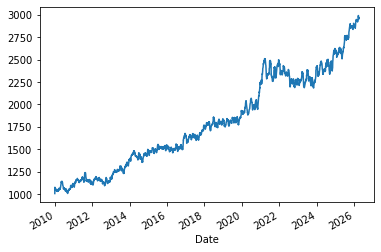

In [14]:
#Creating 5M+ Average Daily Volume Universe
df_universe_5m = (df_average_daily_volume  > 5_000_000).astype(int)
df_universe_5m.sum(axis=1).plot()

In [ ]:
# Saving 5M universe to stores folder
df_universe_5m.to_parquet(os.path.join(DATA_DIR, "universe_5m.parquet"),engine="pyarrow")

<Axes: xlabel='Date'>

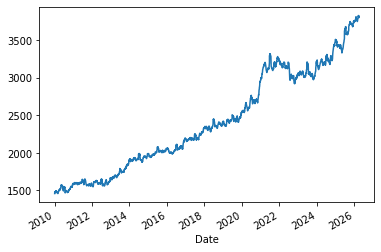

In [47]:
#Creating 1M+ Average Daily Volume Universe
df_universe_1m = (df_average_daily_volume  > 1_000_000).astype(int)
df_universe_1m.sum(axis=1).plot()

In [ ]:
#Saving 1M universe to parquet file
df_universe_1m.to_parquet(os.path.join(DATA_DIR, "universe_1m.parquet"),engine="pyarrow")

In [48]:
#Calculating returns for each ticker every day
returns = pv['Adj Close'].pct_change(fill_method=None).fillna(0)

In [ ]:
#Saving returns to parquet file
returns.to_parquet(os.path.join(DATA_DIR, "returns.parquet"),engine="pyarrow")